In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Download latest version
path = kagglehub.dataset_download("martinellis/nhl-game-data")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/nhl-game-data


In [ ]:
game_csv_path = os.path.join(path + '/game.csv')
game_teams_stats_csv_path = os.path.join(path + '/game_teams_stats.csv')
team_info_csv_path = os.path.join(path + '/team_info.csv')

In [ ]:
game = pd.read_csv(game_csv_path)
game_teams_stats = pd.read_csv(game_teams_stats_csv_path)
team_info = pd.read_csv(team_info_csv_path)

In [ ]:
game.head()

,game_id,season,type,date_time_GMT,away_team_id,home_team_id,away_goals,home_goals,outcome,home_rink_side_start,venue,venue_link,venue_time_zone_id,venue_time_zone_offset,venue_time_zone_tz
0,2016020045,20162017,R,2016-10-19T00:30:00Z,4,16,4,7,home win REG,right,United Center,/api/v1/venues/null,America/Chicago,-5,CDT
1,2017020812,20172018,R,2018-02-07T00:00:00Z,24,7,4,3,away win OT,left,KeyBank Center,/api/v1/venues/null,America/New_York,-4,EDT
2,2015020314,20152016,R,2015-11-24T01:00:00Z,21,52,4,1,away win REG,right,MTS Centre,/api/v1/venues/null,America/Winnipeg,-5,CDT
3,2015020849,20152016,R,2016-02-17T00:00:00Z,52,12,1,2,home win REG,right,PNC Arena,/api/v1/venues/null,America/New_York,-4,EDT
4,2017020586,20172018,R,2017-12-30T03:00:00Z,20,24,1,2,home win REG,left,Honda Center,/api/v1/venues/null,America/Los_Angeles,-7,PDT


In [ ]:
game_teams_stats.head()

,game_id,team_id,HoA,won,settled_in,head_coach,goals,shots,hits,pim,powerPlayOpportunities,powerPlayGoals,faceOffWinPercentage,giveaways,takeaways,blocked,startRinkSide
0,2016020045,4,away,False,REG,Dave Hakstol,4.0,27.0,30.0,6.0,4.0,2.0,50.9,12.0,9.0,11.0,left
1,2016020045,16,home,True,REG,Joel Quenneville,7.0,28.0,20.0,8.0,3.0,2.0,49.1,16.0,8.0,9.0,left
2,2017020812,24,away,True,OT,Randy Carlyle,4.0,34.0,16.0,6.0,3.0,1.0,43.8,7.0,4.0,14.0,right
3,2017020812,7,home,False,OT,Phil Housley,3.0,33.0,17.0,8.0,2.0,1.0,56.2,5.0,6.0,14.0,right
4,2015020314,21,away,True,REG,Patrick Roy,4.0,29.0,17.0,9.0,3.0,1.0,45.7,13.0,5.0,20.0,left


In [ ]:
team_info.head()

,team_id,franchiseId,shortName,teamName,abbreviation,link
0,1,23,New Jersey,Devils,NJD,/api/v1/teams/1
1,4,16,Philadelphia,Flyers,PHI,/api/v1/teams/4
2,26,14,Los Angeles,Kings,LAK,/api/v1/teams/26
3,14,31,Tampa Bay,Lightning,TBL,/api/v1/teams/14
4,6,6,Boston,Bruins,BOS,/api/v1/teams/6


In [ ]:
game_merged_data = pd.merge(game, game_teams_stats, on ='game_id', how = 'outer')
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
print(game_merged_data.head())

      game_id    season type         date_time_GMT  away_team_id  home_team_id  away_goals  home_goals       outcome home_rink_side_start          venue           venue_link venue_time_zone_id  venue_time_zone_offset venue_time_zone_tz  team_id   HoA    won settled_in      head_coach  goals  shots  hits   pim  powerPlayOpportunities  powerPlayGoals  faceOffWinPercentage  giveaways  takeaways  blocked startRinkSide
0  2000020001  20002001    R  2000-10-04T23:00:00Z            21            25           2           2    tbc win OT                right  Reunion Arena  /api/v1/venues/null    America/Chicago                      -5                CDT       21  away  False         OT     Bob Hartley    2.0   28.0   NaN  20.0                    10.0             1.0                   NaN        NaN        NaN      NaN          left
1  2000020001  20002001    R  2000-10-04T23:00:00Z            21            25           2           2    tbc win OT                right  Reunion Arena  /api/v1/ve

In [ ]:
game_merged_data_info = pd.merge(game_merged_data, team_info, left_on='team_id',
                                 right_on='team_id', how='outer')
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
print(game_merged_data_info.head())

      game_id    season type         date_time_GMT  away_team_id  home_team_id  away_goals  home_goals       outcome home_rink_side_start                       venue           venue_link venue_time_zone_id  venue_time_zone_offset venue_time_zone_tz  team_id   HoA    won settled_in      head_coach  goals  shots  hits   pim  powerPlayOpportunities  powerPlayGoals  faceOffWinPercentage  giveaways  takeaways  blocked startRinkSide  franchiseId   shortName teamName abbreviation             link
0  2000020007  20002001    R  2000-10-06T23:00:00Z             8             1           4           8  home win REG                 left  Continental Airlines Arena  /api/v1/venues/null   America/New_York                      -4                EDT        1  home   True        REG  Larry Robinson    8.0   34.0   NaN  26.0                     4.0             1.0                   NaN        NaN        NaN      NaN         right         23.0  New Jersey   Devils          NJD  /api/v1/teams/1
1  2000020

In [ ]:
game_merged_data_info.columns

Index(['game_id', 'season', 'type', 'date_time_GMT', 'away_team_id',
       'home_team_id', 'away_goals', 'home_goals', 'outcome',
       'home_rink_side_start', 'venue', 'venue_link', 'venue_time_zone_id',
       'venue_time_zone_offset', 'venue_time_zone_tz', 'team_id', 'HoA', 'won',
       'settled_in', 'head_coach', 'goals', 'shots', 'hits', 'pim',
       'powerPlayOpportunities', 'powerPlayGoals', 'faceOffWinPercentage',
       'giveaways', 'takeaways', 'blocked', 'startRinkSide', 'franchiseId',
       'shortName', 'teamName', 'abbreviation', 'link'],
      dtype='object')

In [ ]:
print(game_merged_data_info.shape)

(62890, 36)


In [ ]:
#Null values
game_merged_data_info.isnull().sum()

,0
game_id,0
season,0
type,0
date_time_GMT,0
away_team_id,0
home_team_id,0
away_goals,0
home_goals,0
outcome,0
home_rink_side_start,2780


In [ ]:
#Dropping null values
game_merged_data_info.dropna(inplace=True)
print(game_merged_data_info.isnull().sum())

game_id                   0
season                    0
type                      0
date_time_GMT             0
away_team_id              0
home_team_id              0
away_goals                0
home_goals                0
outcome                   0
home_rink_side_start      0
venue                     0
venue_link                0
venue_time_zone_id        0
venue_time_zone_offset    0
venue_time_zone_tz        0
team_id                   0
HoA                       0
won                       0
settled_in                0
head_coach                0
goals                     0
shots                     0
hits                      0
pim                       0
powerPlayOpportunities    0
powerPlayGoals            0
faceOffWinPercentage      0
giveaways                 0
takeaways                 0
blocked                   0
startRinkSide             0
franchiseId               0
shortName                 0
teamName                  0
abbreviation              0
link                

In [ ]:
#Checking for null values
game_merged_data_info.isnull().sum()

,0
game_id,0
season,0
type,0
date_time_GMT,0
away_team_id,0
home_team_id,0
away_goals,0
home_goals,0
outcome,0
home_rink_side_start,0


In [ ]:
game_merged_data_info.head()

,game_id,season,type,date_time_GMT,away_team_id,home_team_id,away_goals,home_goals,outcome,home_rink_side_start,venue,venue_link,venue_time_zone_id,venue_time_zone_offset,venue_time_zone_tz,team_id,HoA,won,settled_in,head_coach,goals,shots,hits,pim,powerPlayOpportunities,powerPlayGoals,faceOffWinPercentage,giveaways,takeaways,blocked,startRinkSide,franchiseId,shortName,teamName,abbreviation,link
738,2010020007,20102011,R,2010-10-08T23:00:00Z,25,1,4,3,away win OT,left,Prudential Center,/api/v1/venues/null,America/New_York,-4,EDT,1,home,False,OT,John MacLean,3.0,30.0,16.0,6.0,1.0,1.0,38.5,4.0,1.0,8.0,right,23.0,New Jersey,Devils,NJD,/api/v1/teams/1
739,2010020017,20102011,R,2010-10-09T23:00:00Z,1,15,2,7,home win REG,right,Verizon Center,/api/v1/venues/null,America/New_York,-4,EDT,1,away,False,REG,John MacLean,2.0,33.0,17.0,45.0,4.0,0.0,44.4,8.0,3.0,13.0,left,23.0,New Jersey,Devils,NJD,/api/v1/teams/1
740,2010020027,20102011,R,2010-10-11T20:00:00Z,5,1,3,1,away win REG,left,Prudential Center,/api/v1/venues/null,America/New_York,-4,EDT,1,home,False,REG,John MacLean,1.0,31.0,24.0,12.0,2.0,0.0,51.0,16.0,6.0,6.0,right,23.0,New Jersey,Devils,NJD,/api/v1/teams/1
741,2010020036,20102011,R,2010-10-13T23:00:00Z,1,7,1,0,away win OT,left,HSBC Arena,/api/v1/venues/null,America/New_York,-4,EDT,1,away,True,OT,John MacLean,1.0,35.0,19.0,9.0,3.0,0.0,52.3,17.0,3.0,18.0,right,23.0,New Jersey,Devils,NJD,/api/v1/teams/1
742,2010020048,20102011,R,2010-10-15T23:00:00Z,21,1,3,2,away win REG,left,Prudential Center,/api/v1/venues/null,America/New_York,-4,EDT,1,home,False,REG,John MacLean,2.0,43.0,9.0,15.0,3.0,1.0,60.0,8.0,7.0,5.0,right,23.0,New Jersey,Devils,NJD,/api/v1/teams/1


In [ ]:
print(game_merged_data_info.shape[0])
print(game_merged_data_info.shape)

39446
(39446, 36)


In [ ]:
#Split the data
X = game_merged_data_info.drop(['game_id', 'away_team_id', 'home_team_id', 'team_id', 'franchiseId', 'season', 'outcome','type', 'date_time_GMT', 'home_rink_side_start', 'venue', 'venue_link', 'venue_time_zone_id', 'venue_time_zone_offset', 'venue_time_zone_tz', 'HoA', 'won', 'settled_in', 'head_coach', 'startRinkSide', 'shortName', 'teamName', 'abbreviation', 'link', 'goals', 'home_goals', 'away_goals', 'powerPlayGoals'], axis=1)
y = game_merged_data_info['won']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X.columns

Index(['shots', 'hits', 'pim', 'powerPlayOpportunities',
       'faceOffWinPercentage', 'giveaways', 'takeaways', 'blocked'],
      dtype='object')

In [ ]:
#Train the model
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
#use the trained model to make predictions on the test set dt
print("\nMaking predictions on the test set...")
dt_y_pred = dt_classifier.predict(X_test)
print("Predictions made.")
print("First 5 predictions:", dt_y_pred[:5])
print("First 5 actual labels", y_test[:5])

#Calculate accuracy dt
accuracy = accuracy_score(y_test, dt_y_pred)
print(f"dt\nModel Accuracy: {accuracy:.4f}")

#Display the confusion matrix (shows the correct/inccorect predictions per class) dt
print(f"dt\nConfusion Matrix:")
dt_cm = confusion_matrix(y_test, dt_y_pred)
print(dt_cm)


Making predictions on the test set...
Predictions made.
First 5 predictions: [ True False False False False]
First 5 actual labels 36814     True
58899     True
47938    False
60570    False
5818     False
Name: won, dtype: bool
dt
Model Accuracy: 0.7636
dt
Confusion Matrix:
[[2991  916]
 [ 949 3034]]


In [ ]:
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
#use the trained model to make predictions on the test set rf
print("\nMaking predictions on the test set...")
rf_y_pred = rf_classifier.predict(X_test)
print("Predictions made.")
print("First 5 predictions:", rf_y_pred[:5])
print("First 5 actual labels", y_test[:5])

#Calculate accuracy rf
accuracy = accuracy_score(y_test, rf_y_pred)
print(f"dt\nModel Accuracy: {accuracy:.4f}")

#Display the confusion matrix (shows the correct/inccorect predictions per class) rf
print(f"rf\nConfusion Matrix:")
rf_cm = confusion_matrix(y_test, rf_y_pred)
print(rf_cm)


Making predictions on the test set...
Predictions made.
First 5 predictions: [False False False False False]
First 5 actual labels 36814     True
58899     True
47938    False
60570    False
5818     False
Name: won, dtype: bool
dt
Model Accuracy: 0.7850
rf
Confusion Matrix:
[[3080  827]
 [ 869 3114]]


In [ ]:
#Difference in rf vs dt
difference_cm = rf_cm - dt_cm
print("Difference in Confusion Matrix:")
print(difference_cm)

Difference in Confusion Matrix:
[[ 89 -89]
 [-80  80]]


In [ ]:
#Split the data no powerplay oppotunities
X1 = game_merged_data_info[['shots', 'hits', 'pim','faceOffWinPercentage', 'giveaways', 'takeaways', 'blocked']]
y1 = game_merged_data_info['won']
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

X1.columns

Index(['shots', 'hits', 'pim', 'faceOffWinPercentage', 'giveaways',
       'takeaways', 'blocked'],
      dtype='object')

In [ ]:
#Train the model
dt_classifier1 = DecisionTreeClassifier(random_state=42)
dt_classifier1.fit(X1_train, y1_train)

#use the trained model to make predictions on the test set dt
print("\nMaking predictions on the test set...")
dt_y_pred1 = dt_classifier1.predict(X1_test)
print("Predictions made.")
print("First 5 predictions:", dt_y_pred1[:5])
print("First 5 actual labels", y1_test[:5])

#Calculate accuracy dt
accuracy1 = accuracy_score(y1_test, dt_y_pred1)
print(f"dt\nModel Accuracy: {accuracy1:.4f}")

#Display the confusion matrix (shows the correct/inccorect predictions per class) dt
print(f"dt\nConfusion Matrix:")
dt_cm1 = confusion_matrix(y1_test, dt_y_pred1)
print(dt_cm1)


Making predictions on the test set...
Predictions made.
First 5 predictions: [ True  True False False False]
First 5 actual labels 36814     True
58899     True
47938    False
60570    False
5818     False
Name: won, dtype: bool
dt
Model Accuracy: 0.7634
dt
Confusion Matrix:
[[2973  934]
 [ 933 3050]]


In [ ]:
#Train the model
rf_classifier1 = RandomForestClassifier(random_state=42)
rf_classifier1.fit(X1_train, y1_train)

#Use the trained model to make predictions on the test set rf
print("\nMaking predictions on the test set...")
rf_y_pred1 = rf_classifier1.predict(X1_test)
print("Predictions made.")
print("First 5 predictions:", rf_y_pred1[:5])
print("First 5 actual labels", y1_test[:5])

#Calculate accuracy rf
accuracy1 = accuracy_score(y1_test, rf_y_pred1)
print(f"rf\nModel Accuracy: {accuracy1:.4f}")

#Display the confusion matrix (shows the correct/inccorect predictions per class) rf
print(f"rf\nConfusion Matrix:")
rf_cm1 = confusion_matrix(y1_test, rf_y_pred1)
print(rf_cm1)


Making predictions on the test set...
Predictions made.
First 5 predictions: [False False False False False]
First 5 actual labels 36814     True
58899     True
47938    False
60570    False
5818     False
Name: won, dtype: bool
rf
Model Accuracy: 0.7909
rf
Confusion Matrix:
[[3116  791]
 [ 859 3124]]


In [ ]:
#Difference in rf vs dt
difference_cm1 = rf_cm1 - dt_cm1
print("Difference in Confusion Matrix:")
print(difference_cm1)

Difference in Confusion Matrix:
[[ 143 -143]
 [ -74   74]]


In [ ]:
dif_rf1_dt = rf_cm1 - dt_cm
print("Difference in Confusion Matrix:")
print(dif_rf1_dt)

Difference in Confusion Matrix:
[[ 125 -125]
 [ -90   90]]


In [ ]:
# Get feature importances from Random Forest
rf_feature_importances = rf_classifier.feature_importances_

# Get feature importances from Decision Tree
dt_feature_importances = dt_classifier.feature_importances_

In [ ]:
# Get the names of the features
feature_names = X_train.columns

In [ ]:
# Create a Pandas Series for Random Forest feature importances
rf_importance_series = pd.Series(rf_feature_importances, index=feature_names)

# Sort the Random Forest feature importances in descending order
rf_sorted_importances = rf_importance_series.sort_values(ascending=False)

print("Random Forest Feature Importances:")
print(rf_sorted_importances)

Random Forest Feature Importances:
faceOffWinPercentage      0.179979
shots                     0.140682
hits                      0.136046
blocked                   0.128104
giveaways                 0.128028
pim                       0.111171
takeaways                 0.098680
powerPlayOpportunities    0.077310
dtype: float64


In [ ]:
# Create a Pandas Series for Decision Tree feature importances
dt_importance_series = pd.Series(dt_feature_importances, index=feature_names)

# Sort the Decision Tree feature importances in descending order
dt_sorted_importances = dt_importance_series.sort_values(ascending=False)

print("Decision Tree Feature Importances:")
print(dt_sorted_importances)

Decision Tree Feature Importances:
faceOffWinPercentage      0.212292
shots                     0.140308
hits                      0.139008
giveaways                 0.133067
pim                       0.110626
blocked                   0.103263
takeaways                 0.083454
powerPlayOpportunities    0.077982
dtype: float64


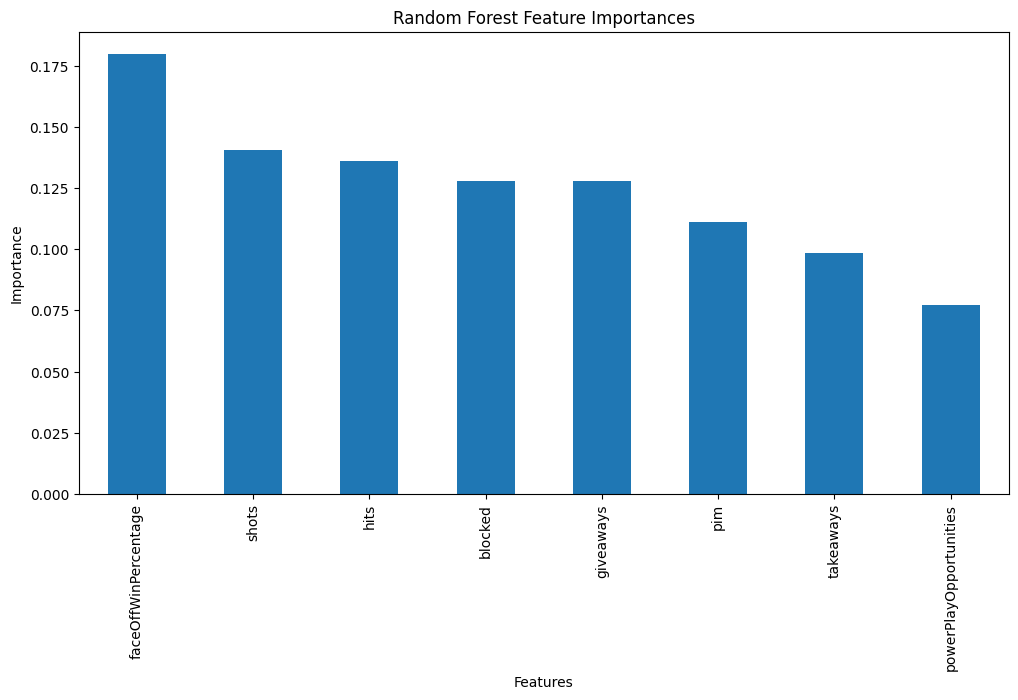

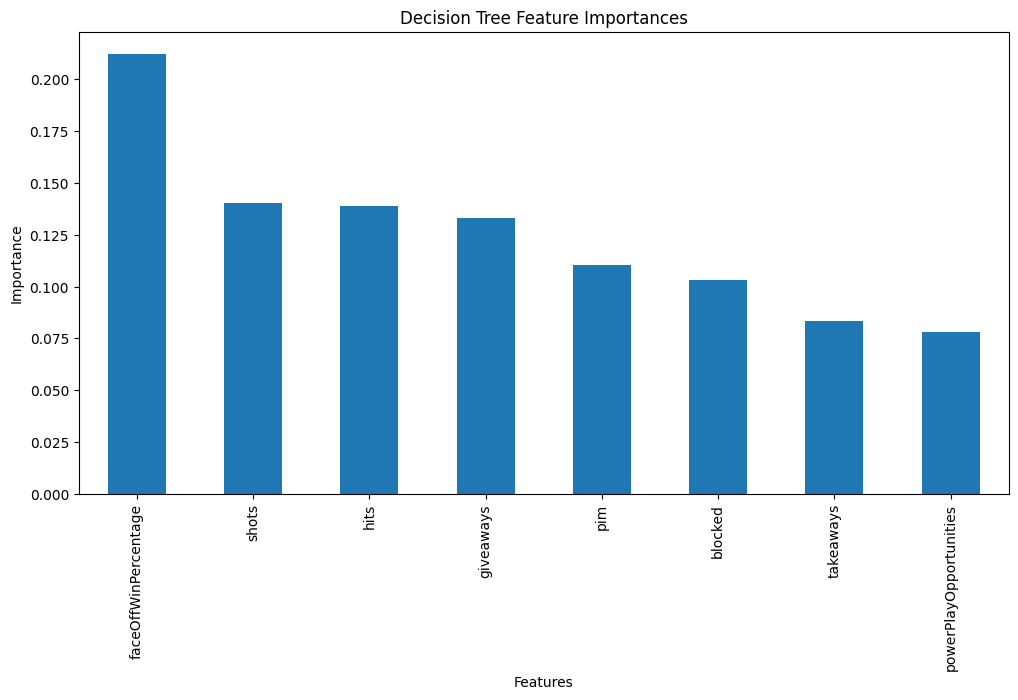

In [ ]:
# Visualize Random Forest feature importances
plt.figure(figsize=(12, 6))
rf_sorted_importances.plot(kind="bar")
plt.title("Random Forest Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

# Visualize Decision Tree feature importances
plt.figure(figsize=(12, 6))
dt_sorted_importances.plot(kind="bar")
plt.title("Decision Tree Feature Importances")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

<Figure size 800x500 with 0 Axes>

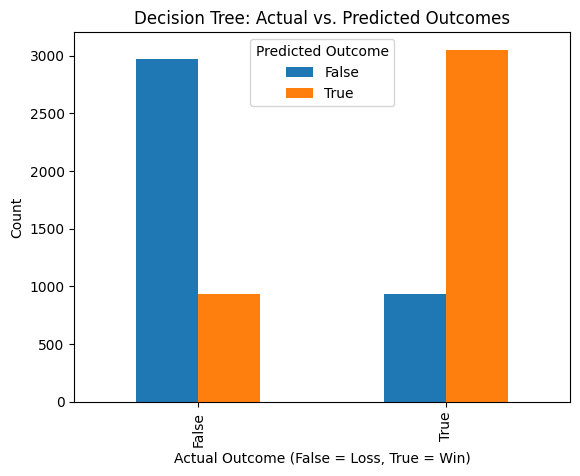

<Figure size 800x500 with 0 Axes>

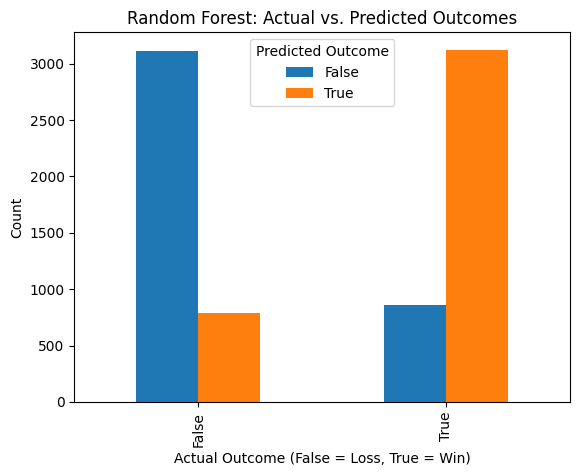

In [ ]:
# Combine actual and predicted values for visualization
dt_results = pd.DataFrame({'Actual': y1_test, 'Predicted': dt_y_pred1})
rf_results = pd.DataFrame({'Actual': y1_test, 'Predicted': rf_y_pred1})

# Count the occurrences of each combination for Decision Tree
dt_counts = dt_results.groupby(['Actual', 'Predicted']).size().unstack(fill_value=0)

# Count the occurrences of each combination for Random Forest
rf_counts = rf_results.groupby(['Actual', 'Predicted']).size().unstack(fill_value=0)

# Plotting for Decision Tree
plt.figure(figsize=(8, 5))
dt_counts.plot(kind='bar')
plt.title('Decision Tree: Actual vs. Predicted Outcomes')
plt.xlabel('Actual Outcome (False = Loss, True = Win)')
plt.ylabel('Count')
plt.legend(title='Predicted Outcome')
plt.show()

# Plotting for Random Forest
plt.figure(figsize=(8, 5))
rf_counts.plot(kind='bar')
plt.title('Random Forest: Actual vs. Predicted Outcomes')
plt.xlabel('Actual Outcome (False = Loss, True = Win)')
plt.ylabel('Count')
plt.legend(title='Predicted Outcome')
plt.show()

In [ ]:
#Split the data no powerplay oppotunities
X2 = game_merged_data_info[['shots', 'hits','faceOffWinPercentage', 'giveaways']]
y2 = game_merged_data_info['won']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

X2.columns

Index(['shots', 'hits', 'faceOffWinPercentage', 'giveaways'], dtype='object')

In [ ]:
#Train the model
dt_classifier2 = DecisionTreeClassifier(random_state=42)
dt_classifier2.fit(X2_train, y2_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
#use the trained model to make predictions on the test set dt
print("\nMaking predictions on the test set...")
dt_y_pred2 = dt_classifier2.predict(X2_test)
print("Predictions made.")
print("First 5 predictions:", dt_y_pred2[:5])
print("First 5 actual labels", y2_test[:5])

#Calculate accuracy dt
accuracy2 = accuracy_score(y2_test, dt_y_pred2)
print(f"dt\nModel Accuracy: {accuracy2:.4f}")

#Display the confusion matrix (shows the correct/inccorect predictions per class) dt
print(f"dt\nConfusion Matrix:")
dt_cm2 = confusion_matrix(y2_test, dt_y_pred2)
print(dt_cm2)


Making predictions on the test set...
Predictions made.
First 5 predictions: [False False False False False]
First 5 actual labels 36814     True
58899     True
47938    False
60570    False
5818     False
Name: won, dtype: bool
dt
Model Accuracy: 0.7466
dt
Confusion Matrix:
[[2928  979]
 [1020 2963]]


In [ ]:
#Train the model
rf_classifier2 = RandomForestClassifier(random_state=42)
rf_classifier2.fit(X2_train, y2_train)

RandomForestClassifier(random_state=42)

In [ ]:
#Use the trained model to make predictions on the test set rf
print("\nMaking predictions on the test set...")
rf_y_pred2 = rf_classifier2.predict(X2_test)
print("Predictions made.")
print("First 5 predictions:", rf_y_pred2[:5])
print("First 5 actual labels", y2_test[:5])

#Calculate accuracy rf
accuracy2 = accuracy_score(y2_test, rf_y_pred2)
print(f"rf\nModel Accuracy: {accuracy2:.4f}")

#Display the confusion matrix (shows the correct/inccorect predictions per class) rf
print(f"rf\nConfusion Matrix:")
rf_cm2 = confusion_matrix(y2_test, rf_y_pred2)
print(rf_cm2)


Making predictions on the test set...
Predictions made.
First 5 predictions: [False False False False False]
First 5 actual labels 36814     True
58899     True
47938    False
60570    False
5818     False
Name: won, dtype: bool
rf
Model Accuracy: 0.7541
rf
Confusion Matrix:
[[2997  910]
 [1030 2953]]


In [ ]:
#Difference in rf vs dt
difference_cm2 = rf_cm2 - dt_cm2
print("Difference in Confusion Matrix:")
print(difference_cm2)

Difference in Confusion Matrix:
[[ 69 -69]
 [ 10 -10]]


In [ ]:
#Split the data no powerplay oppotunities
X3 = game_merged_data_info[['shots', 'hits','faceOffWinPercentage']]
y3 = game_merged_data_info['won']
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)

X3.columns

Index(['shots', 'hits', 'faceOffWinPercentage'], dtype='object')

In [ ]:
#Train the model
dt_classifier3 = DecisionTreeClassifier(random_state=42)
dt_classifier3.fit(X3_train, y3_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
#use the trained model to make predictions on the test set dt
print("\nMaking predictions on the test set...")
dt_y_pred3 = dt_classifier3.predict(X3_test)
print("Predictions made.")
print("First 5 predictions:", dt_y_pred3[:5])
print("First 5 actual labels", y3_test[:5])

#Calculate accuracy dt
accuracy3 = accuracy_score(y3_test, dt_y_pred3)
print(f"dt\nModel Accuracy: {accuracy3:.4f}")

#Display the confusion matrix (shows the correct/inccorect predictions per class) dt
print(f"dt\nConfusion Matrix:")
dt_cm3 = confusion_matrix(y3_test, dt_y_pred3)
print(dt_cm3)


Making predictions on the test set...
Predictions made.
First 5 predictions: [False False False False False]
First 5 actual labels 36814     True
58899     True
47938    False
60570    False
5818     False
Name: won, dtype: bool
dt
Model Accuracy: 0.7412
dt
Confusion Matrix:
[[2943  964]
 [1078 2905]]


In [ ]:
#Train the model
rf_classifier3 = RandomForestClassifier(random_state=42)
rf_classifier3.fit(X3_train, y3_train)

RandomForestClassifier(random_state=42)

In [ ]:
#Use the trained model to make predictions on the test set rf
print("\nMaking predictions on the test set...")
rf_y_pred3 = rf_classifier3.predict(X3_test)
print("Predictions made.")
print("First 5 predictions:", rf_y_pred3[:5])
print("First 5 actual labels", y3_test[:5])

#Calculate accuracy rf
accuracy3 = accuracy_score(y3_test, rf_y_pred3)
print(f"rf\nModel Accuracy: {accuracy3:.4f}")

#Display the confusion matrix (shows the correct/inccorect predictions per class) rf
print(f"rf\nConfusion Matrix:")
rf_cm3 = confusion_matrix(y3_test, rf_y_pred3)
print(rf_cm3)


Making predictions on the test set...
Predictions made.
First 5 predictions: [False False False False False]
First 5 actual labels 36814     True
58899     True
47938    False
60570    False
5818     False
Name: won, dtype: bool
rf
Model Accuracy: 0.7389
rf
Confusion Matrix:
[[2902 1005]
 [1055 2928]]


In [ ]:
#Difference in rf vs dt
difference_cm3 = rf_cm3 - dt_cm3
print("Difference in Confusion Matrix:")
print(difference_cm3)

Difference in Confusion Matrix:
[[-41  41]
 [-23  23]]
